# IEMOCAP Multimodal Feature Visualization

Visualizes text, audio, and visual features from `iemocap_multi_features.pkl` in 2D feature space using PCA and t-SNE. Each point = one utterance, colored by emotion.

## Dataset Structure
| Index | Content | Shape |
|-------|---------|-------|
| data[0] | utterance IDs | — |
| data[1] | speaker (M/F) | — |
| data[2] | emotion labels (0–5) | — |
| data[3] | text features (encoder 0) | (1024,) |
| data[4] | text features (encoder 1) | (1024,) |
| data[5] | text features (encoder 2) | (1024,) |
| data[6] | text features (encoder 3) | (1024,) |
| data[7] | audio features | (1582,) |
| data[8] | visual features | (342,) |
| data[9] | raw sentences | — |
| data[10] | train dialog IDs | — |
| data[11] | test dialog IDs | — |

**Emotion labels:** `{0: anger, 1: happiness, 2: sadness, 3: neutral, 4: frustration, 5: excitement}`

**Total utterances:** ~7433 across 151 dialogs

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = 'Dataset/CFN-ESA/iemocap_multi_features.pkl'

In [2]:
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

videoIDs      = data[0]   # dialog -> [utt_id, ...]
videoSpeakers = data[1]   # dialog -> [M/F, ...]
videoLabels   = data[2]   # dialog -> [int, ...]
videoText0    = data[3]   # dialog -> [1024-dim, ...]
videoText1    = data[4]
videoText2    = data[5]
videoText3    = data[6]
videoAudio    = data[7]   # dialog -> [1582-dim, ...]
videoVisual   = data[8]   # dialog -> [342-dim, ...]
trainVid      = data[10]
testVid       = data[11]

EMOTION_LABELS = {0: 'anger', 1: 'happiness', 2: 'sadness', 3: 'neutral', 4: 'frustration', 5: 'excitement'}
COLORS = {0: '#e74c3c', 1: '#f39c12', 2: '#3498db', 3: '#95a5a6', 4: '#9b59b6', 5: '#2ecc71'}

print(f'Dialogs: {len(videoLabels)}')
print(f'Train dialogs: {len(trainVid)}, Test dialogs: {len(testVid)}')

Dialogs: 151
Train dialogs: 120, Test dialogs: 31


In [3]:
# Flatten all dialogs into utterance-level arrays
text_feats, audio_feats, visual_feats, labels, speakers = [], [], [], [], []

for dialog_id in videoLabels:
    n = len(videoLabels[dialog_id])
    for i in range(n):
        labels.append(videoLabels[dialog_id][i])
        speakers.append(videoSpeakers[dialog_id][i])
        # average 4 text encoders
        avg_text = np.mean([
            videoText0[dialog_id][i],
            videoText1[dialog_id][i],
            videoText2[dialog_id][i],
            videoText3[dialog_id][i],
        ], axis=0)
        text_feats.append(avg_text)
        audio_feats.append(videoAudio[dialog_id][i])
        visual_feats.append(videoVisual[dialog_id][i])

text_feats   = np.array(text_feats)    # (N, 1024)
audio_feats  = np.array(audio_feats)   # (N, 1582)
visual_feats = np.array(visual_feats)  # (N, 342)
labels       = np.array(labels)        # (N,)
speakers     = np.array(speakers)

print(f'Total utterances: {len(labels)}')
print(f'Text: {text_feats.shape}, Audio: {audio_feats.shape}, Visual: {visual_feats.shape}')
print('\nLabel distribution:')
for k, v in EMOTION_LABELS.items():
    count = (labels == k).sum()
    print(f'  {k} {v:12s}: {count:4d} ({100*count/len(labels):.1f}%)')

Total utterances: 7433
Text: (7433, 1024), Audio: (7433, 1582), Visual: (7433, 342)

Label distribution:
  0 anger       :  648 (8.7%)
  1 happiness   : 1084 (14.6%)
  2 sadness     : 1708 (23.0%)
  3 neutral     : 1103 (14.8%)
  4 frustration : 1041 (14.0%)
  5 excitement  : 1849 (24.9%)


In [4]:
def reduce_pca(X, n_components=2):
    X_scaled = StandardScaler().fit_transform(X)
    return PCA(n_components=n_components, random_state=42).fit_transform(X_scaled)

def reduce_tsne(X, perplexity=40, max_iter=1000):
    X_scaled = StandardScaler().fit_transform(X)
    # PCA to 50 dims first for speed
    if X_scaled.shape[1] > 50:
        X_scaled = PCA(n_components=50, random_state=42).fit_transform(X_scaled)
    return TSNE(n_components=2, perplexity=perplexity, max_iter=max_iter, random_state=42).fit_transform(X_scaled)

print('Running PCA on text features...')
text_pca = reduce_pca(text_feats)
print('Running PCA on audio features...')
audio_pca = reduce_pca(audio_feats)
print('Running PCA on visual features...')
visual_pca = reduce_pca(visual_feats)
print('PCA done.')

Running PCA on text features...
Running PCA on audio features...
Running PCA on visual features...
PCA done.


In [5]:
print('Running t-SNE on text features...')
text_tsne = reduce_tsne(text_feats)
print('Running t-SNE on audio features...')
audio_tsne = reduce_tsne(audio_feats)
print('Running t-SNE on visual features...')
visual_tsne = reduce_tsne(visual_feats)
print('t-SNE done.')

Running t-SNE on text features...
Running t-SNE on audio features...
Running t-SNE on visual features...
t-SNE done.


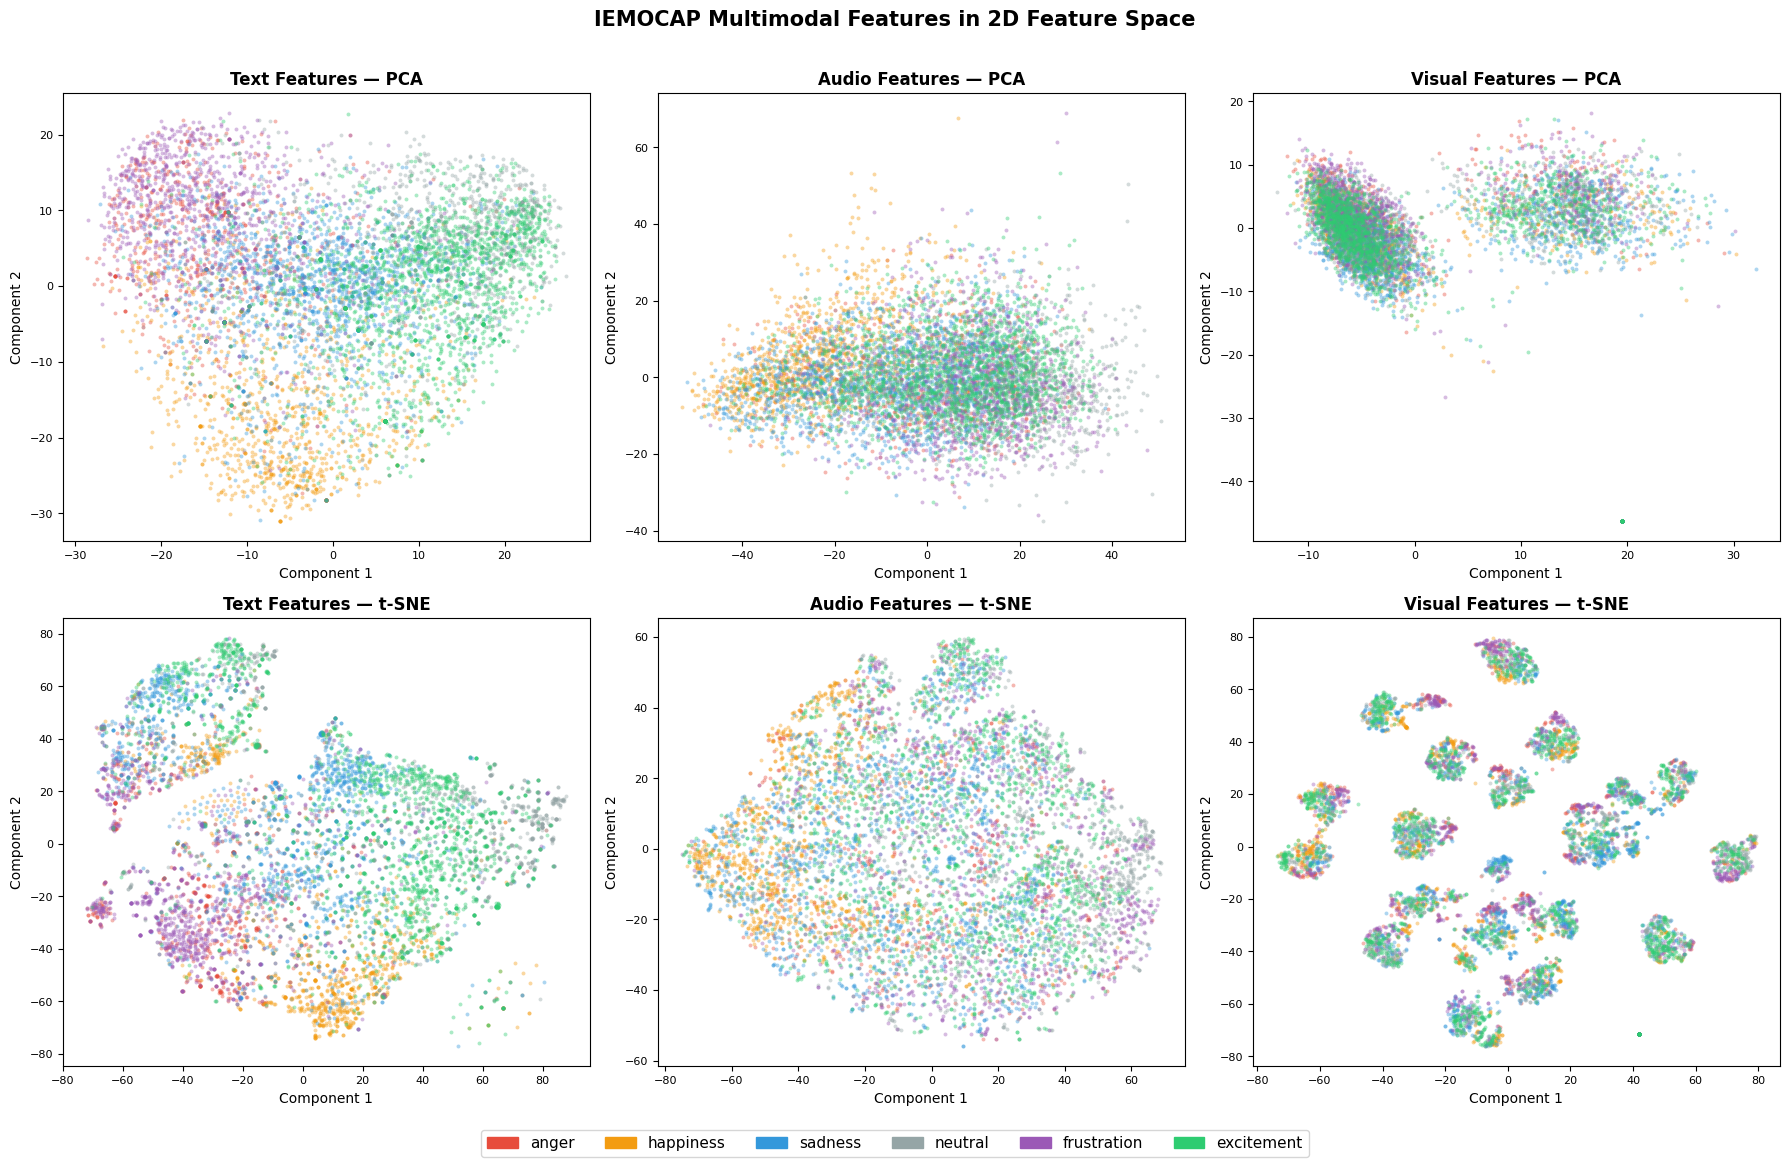

Saved: feature_visualization.png


In [6]:
def scatter_plot(ax, coords, labels, title, alpha=0.4, s=8):
    for emo_id, emo_name in EMOTION_LABELS.items():
        mask = labels == emo_id
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=COLORS[emo_id], label=emo_name,
                   alpha=alpha, s=s, linewidths=0)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.tick_params(labelsize=8)

legend_patches = [mpatches.Patch(color=COLORS[k], label=v) for k, v in EMOTION_LABELS.items()]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('IEMOCAP Multimodal Features in 2D Feature Space', fontsize=15, fontweight='bold', y=1.01)

scatter_plot(axes[0, 0], text_pca,   labels, 'Text Features — PCA')
scatter_plot(axes[0, 1], audio_pca,  labels, 'Audio Features — PCA')
scatter_plot(axes[0, 2], visual_pca, labels, 'Visual Features — PCA')

scatter_plot(axes[1, 0], text_tsne,   labels, 'Text Features — t-SNE')
scatter_plot(axes[1, 1], audio_tsne,  labels, 'Audio Features — t-SNE')
scatter_plot(axes[1, 2], visual_tsne, labels, 'Visual Features — t-SNE')

fig.legend(handles=legend_patches, loc='lower center', ncol=6,
           fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig('feature_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_visualization.png')

In [7]:
# Per-modality variance explained by top 2 PCA components
from sklearn.decomposition import PCA as _PCA

for name, X in [('Text', text_feats), ('Audio', audio_feats), ('Visual', visual_feats)]:
    Xs = StandardScaler().fit_transform(X)
    pca = _PCA(n_components=2, random_state=42).fit(Xs)
    var = pca.explained_variance_ratio_.sum() * 100
    print(f'{name:8s}: PC1+PC2 explains {var:.1f}% of variance  (dim {X.shape[1]})')

Text    : PC1+PC2 explains 28.7% of variance  (dim 1024)
Audio   : PC1+PC2 explains 32.0% of variance  (dim 1582)
Visual  : PC1+PC2 explains 39.6% of variance  (dim 342)


In [8]:
# t-SNE per emotion: show centroid and spread (std) in t-SNE space
print('t-SNE cluster stats (mean ± std of each emotion):\n')
for modality, tsne in [('Text', text_tsne), ('Audio', audio_tsne), ('Visual', visual_tsne)]:
    print(f'--- {modality} ---')
    for emo_id, emo_name in EMOTION_LABELS.items():
        pts = tsne[labels == emo_id]
        print(f'  {emo_name:12s}: n={len(pts):4d}  centroid=({pts[:,0].mean():6.1f}, {pts[:,1].mean():6.1f})  std=({pts[:,0].std():5.1f}, {pts[:,1].std():5.1f})')
    print()

t-SNE cluster stats (mean ± std of each emotion):

--- Text ---
  anger       : n= 648  centroid=( -30.9,  -14.7)  std=( 24.2,  30.0)
  happiness   : n=1084  centroid=(   1.5,  -28.0)  std=( 27.0,  38.0)
  sadness     : n=1708  centroid=(  -8.9,   11.7)  std=( 30.7,  32.3)
  neutral     : n=1103  centroid=(  33.5,   12.1)  std=( 42.2,  28.4)
  frustration : n=1041  centroid=( -34.3,  -14.2)  std=( 25.4,  27.9)
  excitement  : n=1849  centroid=(  18.6,    9.3)  std=( 34.8,  33.9)

--- Audio ---
  anger       : n= 648  centroid=(  -2.5,   -4.7)  std=( 31.4,  25.0)
  happiness   : n=1084  centroid=( -35.4,    3.8)  std=( 23.6,  22.8)
  sadness     : n=1708  centroid=( -10.3,   -1.3)  std=( 29.1,  25.2)
  neutral     : n=1103  centroid=(  23.2,   -1.2)  std=( 29.9,  24.1)
  frustration : n=1041  centroid=(  16.1,   -0.3)  std=( 28.7,  28.9)
  excitement  : n=1849  centroid=(   6.2,    2.6)  std=( 28.6,  26.8)

--- Visual ---
  anger       : n= 648  centroid=(  -4.1,    4.5)  std=( 34.1,  3

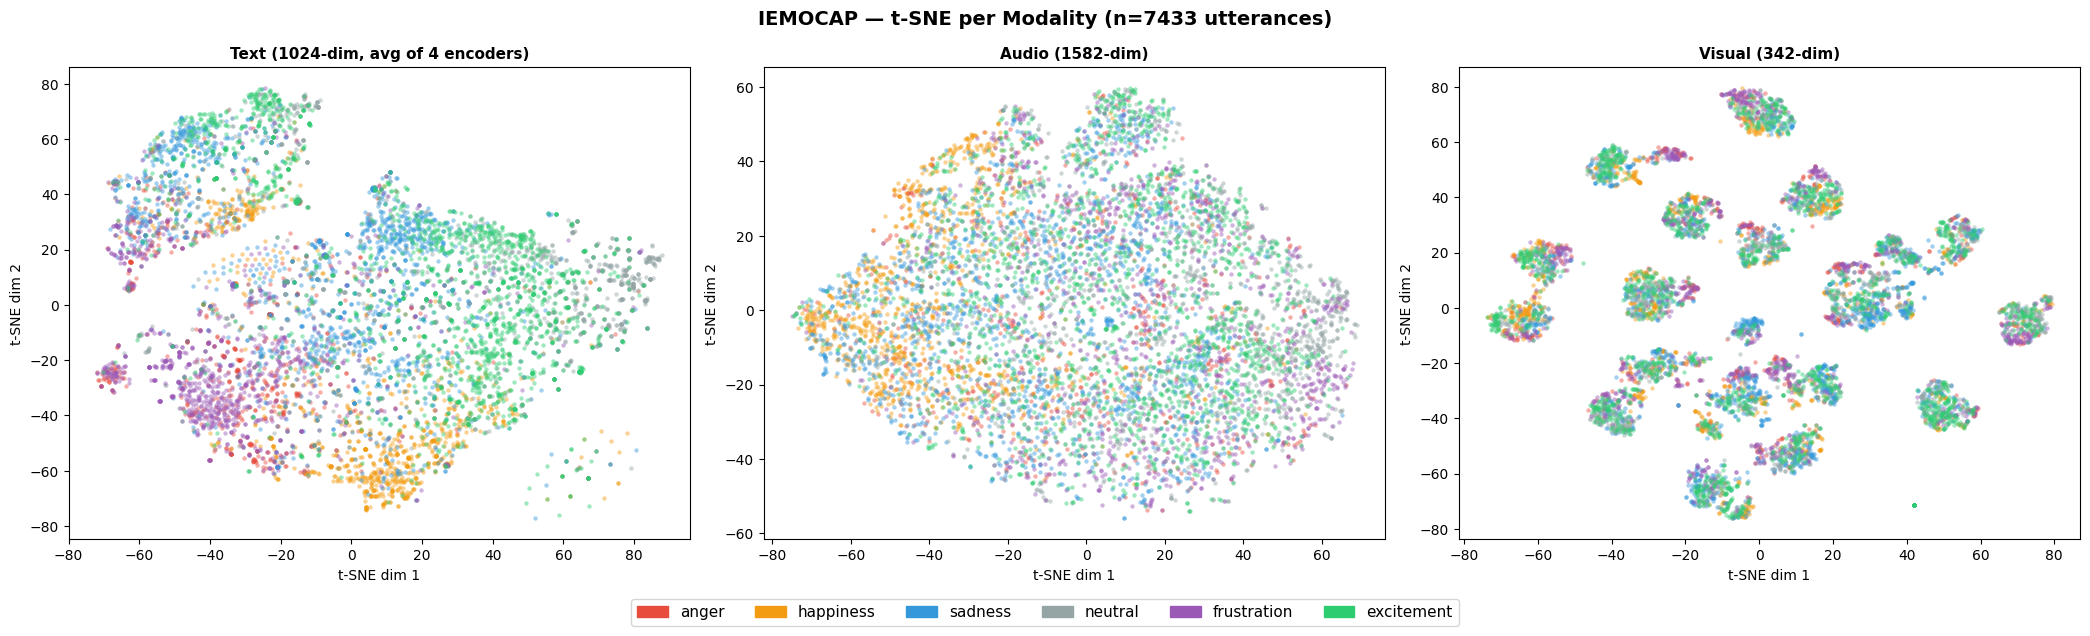

Saved: feature_visualization_tsne_detail.png


In [9]:
# Individual modality t-SNE plots — larger, with density contours
try:
    from scipy.stats import gaussian_kde
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

modalities = [
    ('Text (1024-dim, avg of 4 encoders)', text_tsne),
    ('Audio (1582-dim)',                   audio_tsne),
    ('Visual (342-dim)',                   visual_tsne),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('IEMOCAP — t-SNE per Modality (n=7433 utterances)', fontsize=14, fontweight='bold')

for ax, (title, coords) in zip(axes, modalities):
    for emo_id, emo_name in EMOTION_LABELS.items():
        mask = labels == emo_id
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=COLORS[emo_id], label=emo_name,
                   alpha=0.45, s=10, linewidths=0)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')

fig.legend(handles=legend_patches, loc='lower center', ncol=6,
           fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.savefig('feature_visualization_tsne_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_visualization_tsne_detail.png')

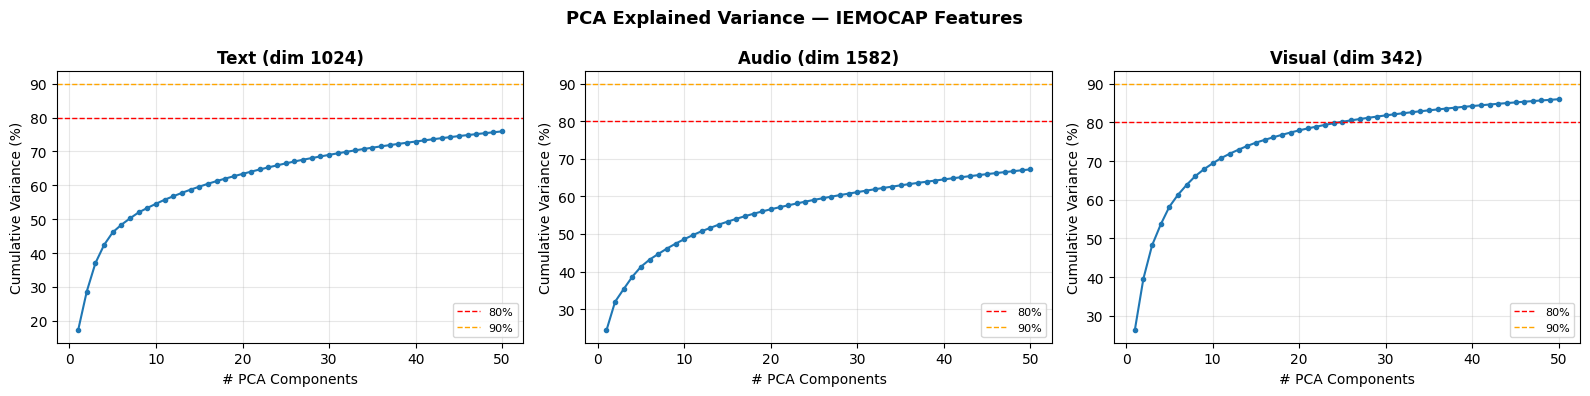

Saved: feature_pca_variance.png


In [10]:
# PCA: show % variance explained across top-50 components per modality
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('PCA Explained Variance — IEMOCAP Features', fontsize=13, fontweight='bold')

for ax, (name, X) in zip(axes, [('Text', text_feats), ('Audio', audio_feats), ('Visual', visual_feats)]):
    n_comp = min(50, X.shape[1])
    Xs = StandardScaler().fit_transform(X)
    pca = _PCA(n_components=n_comp, random_state=42).fit(Xs)
    cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
    ax.plot(range(1, n_comp+1), cumvar, marker='o', markersize=3, linewidth=1.5)
    ax.axhline(80, color='red', linestyle='--', linewidth=1, label='80%')
    ax.axhline(90, color='orange', linestyle='--', linewidth=1, label='90%')
    ax.set_title(f'{name} (dim {X.shape[1]})', fontweight='bold')
    ax.set_xlabel('# PCA Components')
    ax.set_ylabel('Cumulative Variance (%)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('feature_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_pca_variance.png')